In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [28]:
# This assumes that train.csv and test.csv are in the same folder as this notebook
train = pd.read_csv('train.csv', index_col='ID')
test = pd.read_csv('test.csv', index_col='ID')

In [29]:
train.head()

,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,...,p32,p33,p34,p35,p36,p37,p38,p39,p40,p50
ID,,,,,,,,,,,,,,,,,,,,,
0,95.44,98.63,102.79,99.71,96.48,93.32,88.99,84.61,83.39,82.91,...,90.57,86.88,86.27,83.42,80.25,76.95,73.69,69.15,67.07,56.62
1,104.11,104.35,104.32,104.55,103.28,99.04,96.37,97.07,96.48,92.71,...,65.94,70.90,70.07,69.43,69.45,68.24,68.39,72.00,71.67,52.60
2,109.64,109.58,110.92,108.53,104.98,102.64,107.21,107.96,114.28,111.60,...,117.49,117.19,120.93,122.84,124.58,126.50,130.17,131.77,136.22,125.94
3,104.99,103.48,104.35,104.64,104.90,101.73,100.89,104.89,105.02,105.51,...,106.08,108.09,108.14,109.10,108.68,111.60,115.23,117.05,119.02,138.97
4,108.99,102.78,99.99,98.17,94.41,95.75,96.35,98.10,98.85,94.94,...,100.85,97.59,96.23,94.31,97.42,100.85,104.61,108.91,111.31,120.89


In [30]:
train.describe()

,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,...,p32,p33,p34,p35,p36,p37,p38,p39,p40,p50
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,100.001667,99.998473,99.969712,99.931457,99.880003,99.865940,99.848891,99.815983,99.794084,99.779463,...,99.604238,99.577894,99.560079,99.540622,99.528412,99.514691,99.513920,99.524270,99.537554,99.580297
std,6.138997,7.148818,8.315946,9.509276,10.682264,11.775728,12.894025,13.961831,14.919703,15.807330,...,29.937890,30.401620,30.856418,31.352193,31.880285,32.373004,32.903792,33.414083,33.929590,38.512791
min,85.290000,79.710000,73.920000,72.780000,67.350000,65.350000,60.580000,61.510000,55.330000,51.870000,...,4.570000,3.230000,2.910000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,94.980000,94.727500,93.960000,93.137500,92.160000,91.340000,90.410000,89.500000,88.880000,88.247500,...,78.605000,78.340000,77.875000,77.565000,77.300000,76.977500,76.610000,76.347500,75.917500,72.517500
50%,99.970000,100.050000,100.005000,99.890000,99.985000,100.040000,99.900000,100.050000,99.975000,99.765000,...,99.825000,99.900000,99.670000,99.705000,99.595000,99.515000,99.465000,99.685000,99.665000,99.835000
75%,105.090000,105.352500,105.980000,106.842500,107.662500,108.622500,109.320000,110.002500,110.660000,111.340000,...,120.577500,120.940000,121.515000,121.830000,122.095000,122.412500,122.822500,122.850000,123.117500,126.075000
max,114.810000,120.300000,126.890000,128.610000,129.780000,132.080000,137.220000,138.870000,146.430000,143.970000,...,196.200000,195.640000,199.330000,199.640000,203.130000,207.050000,211.140000,215.640000,220.070000,249.950000


In [31]:
import numpy as np
train["signal"] = train["p40"] - 100

In [32]:
stocks = train[train["signal"] < 0]

In [ ]:
zeroes = stocks[stocks["p40"] == 0]
zeroes
zer

,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,...,p33,p34,p35,p36,p37,p38,p39,p40,p50,signal
ID,,,,,,,,,,,,,,,,,,,,,
605,103.33,108.07,104.91,101.88,97.82,94.47,91.15,88.62,87.34,85.80,...,14.00,6.17,0.00,0.00,0.00,0.00,0.00,0.0,0.0,-100.0
2499,102.39,99.81,96.72,92.03,91.85,87.24,84.46,82.65,78.15,75.75,...,14.37,12.12,10.16,7.62,5.89,4.06,0.09,0.0,0.0,-100.0
3045,91.51,93.19,90.68,88.04,83.85,79.74,78.44,76.70,73.62,70.37,...,3.98,3.54,4.61,4.41,0.50,0.07,0.00,0.0,0.0,-100.0
6769,101.01,100.18,100.21,94.80,91.77,91.43,83.98,83.93,79.90,79.32,...,27.40,20.47,14.23,8.77,8.83,6.28,2.38,0.0,0.0,-100.0
8927,89.87,85.63,82.42,78.06,75.54,71.57,69.55,66.09,61.89,59.38,...,6.10,2.91,2.67,3.32,3.50,1.26,0.00,0.0,0.0,-100.0
9376,90.79,84.45,81.78,82.71,80.01,77.06,75.56,73.53,71.75,68.58,...,12.02,10.82,11.95,7.68,7.89,3.62,1.19,0.0,0.0,-100.0


In [42]:
test["signal"] = test["p40"] - 100
stocks_test = test[test["signal"] < 0]
test_zeroes = stocks_test[stocks_test["p40"] == 0]
test_zeroes

,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,...,p32,p33,p34,p35,p36,p37,p38,p39,p40,signal
ID,,,,,,,,,,,,,,,,,,,,,
55,93.58,90.15,86.10,81.59,79.19,73.29,68.54,66.10,62.37,59.84,...,23.62,20.14,16.71,12.85,8.48,0.00,0.00,0.00,0.0,-100.0
3000,89.52,85.02,81.74,79.24,74.57,71.99,67.69,68.34,65.46,61.64,...,11.26,6.85,6.50,4.71,2.65,0.66,0.46,0.54,0.0,-100.0
3403,93.73,93.41,95.56,94.43,91.07,87.43,84.91,81.79,78.80,76.61,...,24.07,20.27,16.02,16.19,11.95,7.84,5.81,3.06,0.0,-100.0
3404,98.30,98.82,94.79,94.38,90.89,86.20,83.73,80.58,77.88,73.83,...,17.87,17.19,16.22,13.62,10.04,6.32,4.22,2.26,0.0,-100.0
4444,92.49,88.86,83.57,80.97,77.33,73.81,70.84,67.57,64.02,61.29,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,-100.0
5993,100.29,98.89,96.10,88.65,90.40,87.94,82.87,80.16,76.47,71.67,...,13.00,9.57,8.96,6.04,3.44,0.00,0.00,0.00,0.0,-100.0
7327,95.08,92.56,88.72,86.60,82.80,80.22,76.64,76.28,76.90,78.82,...,22.08,17.32,15.80,12.87,9.80,8.73,8.01,2.48,0.0,-100.0


<Axes: xlabel='ID'>

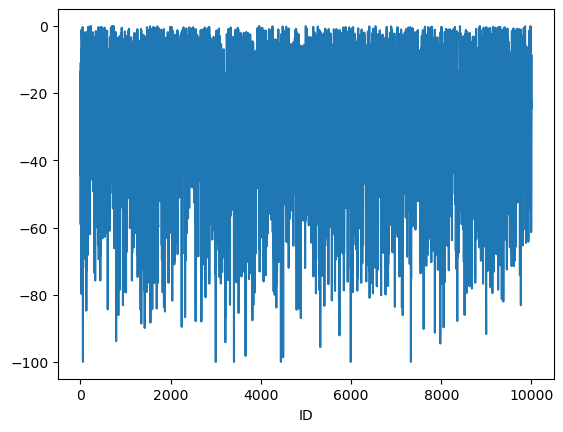

In [46]:
stocks_test["signal"].plot()